# UV Mapping y Tipos de Materiales
## Objetivos
- Entender cómo se proyectan texturas en la superficie de un modelo.  
- Diferenciar materiales básicos y avanzados.  

## Explicación
- **UV Mapping**: coordenadas 2D en cada vértice; unwrap, tiling, overlapping, lightmap UVs.  
- **Tipos de materiales**:  
  - *Unlit* (sin luces, solo textura).  
  - *Lit PBR* (albedo, metallic, roughness, normal, AO).  
  - *Transparent/Alpha blended* (vidrio, agua).  
  - Shader Graph personalizados (toon, stylized).  
- **Material instancing** y variantes (`shader_feature`, `multi_compile`).  

## ¿Qué es UV Mapping?
* UV = coordenadas 2D por vértice que indexan una textura.
* El rasterizador interpola UV por fragmento.
* Conceptos: unwrap, islas, seams, stretch.

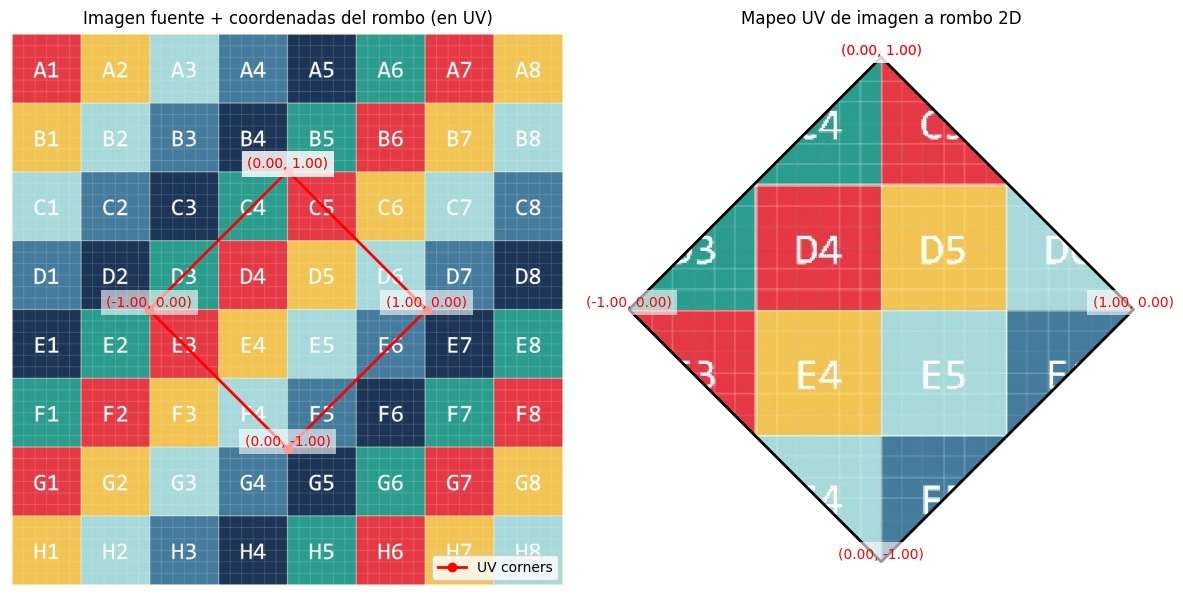

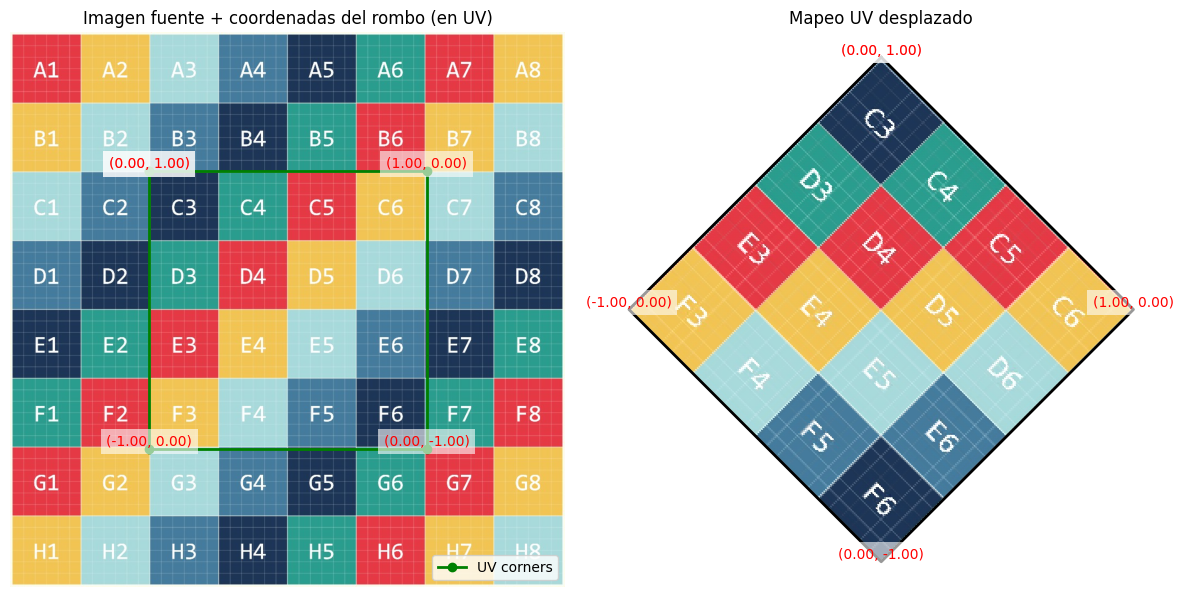

In [16]:
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.path import Path
from scipy.spatial import Delaunay

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Cargar imagen
img = mpimg.imread("checker.jpg")

# Definir vértices del rombo en 2D (centro en (0,0))
rombo = np.array([
    [0, 1],    # Arriba
    [1, 0],    # Derecha
    [0, -1],   # Abajo
    [-1, 0],   # Izquierda
    [0, 1]     # Cierra el rombo
])

# Definir coordenadas UV correspondientes (normalizadas 0-1)
uvs = np.array([
    [0.5, 0.75],   # Arriba
    [0.75, 0.5],   # Derecha
    [0.5, 0.25],   # Abajo
    [0.25, 0.5],   # Izquierda
    [0.5, 0.75]    # Cierra el rombo
])

# Crear una malla dentro del rombo usando interpolación de coordenadas baricéntricas

# Crear una cuadrícula de puntos
res = 300
x = np.linspace(-1, 1, res)
y = np.linspace(-1, 1, res)
xx, yy = np.meshgrid(x, y)
pts = np.stack([xx.ravel(), yy.ravel()], axis=-1)

# Máscara: puntos dentro del rombo
p = Path(rombo)
mask = p.contains_points(pts)
pts_in = pts[mask]

# Interpolación lineal de UVs para cada punto dentro del rombo
def bilinear_interp(p, verts, uvs):
    # Rombo se puede dividir en dos triángulos
    tri = Delaunay(verts[:4])
    simplex = tri.find_simplex(p)
    X = tri.transform[simplex, :2]
    Y = p - tri.transform[simplex, 2]
    bary = np.einsum('ijk,ik->ij', X, Y)
    bary_coords = np.c_[bary, 1 - bary.sum(axis=1)]
    uv = (uvs[:4][tri.simplices[simplex]] * bary_coords[:,:,None]).sum(axis=1)
    return uv

uv_in = bilinear_interp(pts_in, rombo[:4], uvs[:4])

# Mapear UV a píxeles de la imagen
h, w = img.shape[:2]
u_pix = np.clip((uv_in[:,0] * (w-1)).astype(int), 0, w-1)
v_pix = np.clip(((1-uv_in[:,1]) * (h-1)).astype(int), 0, h-1)
color = img[v_pix, u_pix]

# Visualizar
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Imagen fuente con overlay de UVs
axs[0].imshow(img)
axs[0].plot(uvs[:,0]*img.shape[1], (1-uvs[:,1])*img.shape[0], 'ro-', lw=2, label='UV corners')
# Etiquetas de coordenadas UV (pero usando las coordenadas del rombo)
for i, (u, v) in enumerate(uvs):
    axs[0].text(u*img.shape[1], (1-v)*img.shape[0], f"({rombo[i,0]:.2f}, {rombo[i,1]:.2f})", color='red', fontsize=10, ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
axs[0].set_title("Imagen fuente + coordenadas del rombo (en UV)")
axs[0].set_axis_off()
axs[0].legend(loc='lower right')

# Mapeo resultante
axs[1].scatter(pts_in[:,0], pts_in[:,1], c=color/255.0, s=1)
axs[1].plot(rombo[:,0], rombo[:,1], 'k-', lw=2)
# Etiquetas de coordenadas de los vértices del rombo
for i, (x, y) in enumerate(rombo):
    axs[1].text(x, y, f"({x:.2f}, {y:.2f})", color='red', fontsize=10, ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
axs[1].set_title("Mapeo UV de imagen a rombo 2D")
axs[1].set_aspect('equal')
axs[1].set_axis_off()

plt.tight_layout()
plt.show()

# Cambio de coordenadas UV para ver efecto
# Cambia las UVs para que cada vértice del rombo quede en una esquina del mapa UV
uvs_corners = np.array([
    [0.25, 0.75],   # Arriba -> esquina superior izquierda
    [0.75, 0.75],   # Derecha -> esquina superior derecha
    [0.75, 0.25],   # Abajo -> esquina inferior derecha
    [0.25, 0.25],   # Izquierda -> esquina inferior izquierda
    [0.25, 0.75]    # Cierra el rombo
])

uv_in_corners = bilinear_interp(pts_in, rombo[:4], uvs_corners[:4])

# Mapear UV a píxeles de la imagen
u_pix_corners = np.clip((uv_in_corners[:,0] * (w-1)).astype(int), 0, w-1)
v_pix_corners = np.clip(((1-uv_in_corners[:,1]) * (h-1)).astype(int), 0, h-1)
color_corners = img[v_pix_corners, u_pix_corners]

# Visualizar resultado
fig1, axs2 = plt.subplots(1, 2, figsize=(12, 6))

# Imagen fuente con overlay de UVs
axs2[0].imshow(img)
axs2[0].plot(uvs_corners[:,0]*img.shape[1], (1-uvs_corners[:,1])*img.shape[0], 'go-', lw=2, label='UV corners')
# Etiquetas de coordenadas UV (pero usando las coordenadas del rombo)
for i, (u, v) in enumerate(uvs_corners):
    axs2[0].text(u*img.shape[1], (1-v)*img.shape[0], f"({rombo[i,0]:.2f}, {rombo[i,1]:.2f})", color='red', fontsize=10, ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
axs2[0].set_title("Imagen fuente + coordenadas del rombo (en UV)")
axs2[0].set_axis_off()
axs2[0].legend(loc='lower right')

# Mapeo resultante con UVs en esquinas
axs2[1].scatter(pts_in[:,0], pts_in[:,1], c=color_corners/255.0, s=1)
axs2[1].plot(rombo[:,0], rombo[:,1], 'k-', lw=2)
# Etiquetas de coordenadas de los vértices del rombo
for i, (x, y) in enumerate(rombo):
    axs2[1].text(x, y, f"({x:.2f}, {y:.2f})", color='red', fontsize=10, ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
axs2[1].set_title("Mapeo UV desplazado")
axs2[1].set_aspect('equal')
axs2[1].set_axis_off()

plt.tight_layout()
plt.show()


## PyThreejs

Cubos extraidos de <https://github.com/garykac/3d-cubes>

### Formato .obj (Wavefront OBJ)

Es un formato de archivo 3D de texto plano muy usado porque es simple y ampliamente soportado.

Define la geometría de un modelo:

* v → vértices (posición 3D).
* vn → normales de los vértices.
* vt → coordenadas UV (para mapear texturas 2D).
* f → caras (triángulos o polígonos), referenciando índices de vértices/UVs/normales.

No contiene jerarquías complejas ni animación (solo geometría + referencias).

[.\cube.obj](.\cube.obj):
```obj
# cube.obj
# Import into Blender with Y-forward, Z-up
#
# Vertices:                        Faces:
#      f-------g                          +-------+ 
#     /.      /|                         /.  5   /|  3 back
#    / .     / |                        / .     / |
#   e-------h  |                   2   +-------+ 1|
#   |  b . .|. c      z          right |  . . .|. +
#   | .     | /       | /y             | . 4   | /
#   |.      |/        |/               |.      |/
#   a-------d         +---- x          +-------+
#                                           6
#                                        bottom

g cube

# Vertices
v 0.0 0.0 0.0  # 1 a
v 0.0 1.0 0.0  # 2 b
v 1.0 1.0 0.0  # 3 c
v 1.0 0.0 0.0  # 4 d
v 0.0 0.0 1.0  # 5 e
v 0.0 1.0 1.0  # 6 f
v 1.0 1.0 1.0  # 7 g
v 1.0 0.0 1.0  # 8 h

# Normal vectors
# One for each face. Shared by all vertices in that face.
vn  1.0  0.0  0.0  # 1 cghd
vn -1.0  0.0  0.0  # 2 aefb
vn  0.0  1.0  0.0  # 3 gcbf
vn  0.0 -1.0  0.0  # 4 dhea
vn  0.0  0.0  1.0  # 5 hgfe
vn  0.0  0.0 -1.0  # 6 cdab

# Faces v/vt/vn
#   3-------2
#   | -     |
#   |   #   |  Each face = 2 triangles (ccw)
#   |     - |            = 1-2-3 + 1-3-4
#   4-------1

# Face 1: cghd = cgh + chd
f 3//1 7//1 8//1
f 3//1 8//1 4//1

# Face 2: aefb = aef + afb
f 1//2 5//2 6//2
f 1//2 6//2 2//2

# Face 3: gcbf = gcb + gbf
f 7//3 3//3 2//3
f 7//3 2//3 6//3

# Face 4: dhea = dhe + dea
f 4//4 8//4 5//4
f 4//4 5//4 1//4

# Face 5: hgfe = hgf + hfe
f 8//5 7//5 6//5
f 8//5 6//5 5//5

# Face 6: cdab = cda + cab
f 3//6 4//6 1//6
f 3//6 1//6 2//6
```

[./cube-tex.obj](./cube-tex.obj):
```obj
# cube-tex.obj
# Import into Blender with Y-forward, Z-up
#
# Vertices:                        Faces:
#      f-------g                          +-------+ 
#     /.      /|                         /.  5   /|  3 back
#    / .     / |                        / .     / |
#   e-------h  |                   2   +-------+ 1|
#   |  b . .|. c      z          right |  . . .|. +
#   | .     | /       | /y             | . 4   | /
#   |.      |/        |/               |.      |/
#   a-------d         +---- x          +-------+
#                                           6
#                                        bottom

# Material defined in separate file.
mtllib cube.mtl

g cube

# Vertices
v 0.0 0.0 0.0  # 1 a
v 0.0 1.0 0.0  # 2 b
v 1.0 1.0 0.0  # 3 c
v 1.0 0.0 0.0  # 4 d
v 0.0 0.0 1.0  # 5 e
v 0.0 1.0 1.0  # 6 f
v 1.0 1.0 1.0  # 7 g
v 1.0 0.0 1.0  # 8 h

# Normal vectors
# One for each face. Shared by all vertices in that face.
vn  1.0  0.0  0.0  # 1 cghd
vn -1.0  0.0  0.0  # 2 aefb
vn  0.0  1.0  0.0  # 3 gcbf
vn  0.0 -1.0  0.0  # 4 dhea
vn  0.0  0.0  1.0  # 5 hgfe
vn  0.0  0.0 -1.0  # 6 cdab

# Texture
# (u,v) coordinate into texture map image, ranging from 0.0 - 1.0.
#  +---f---g---+---+
#  |   | 5 |   |   |
#  f---e---h---g---+
#  | 2 | 4 | 1 |   |     v
#  b---a---d---c---+     |
#  |   | 6 |   |   |     |
#  +---b---c---+---+     +---- u
#  |   | 3 |   |   |
#  +---f---g---+---+
vt 0.25 1.00  # 1 f(5) = f for face 5
vt 0.50 1.00  # 2 g(5)
vt 0    0.75  # 3 f(2)
vt 0.25 0.75  # 4 e(2,4,5)
vt 0.50 0.75  # 5 h(1,4,5)
vt 0.75 0.75  # 6 g(1)
vt 0    0.50  # 7 b(2)
vt 0.25 0.50  # 8 a(2,4,6)
vt 0.50 0.50  # 9 d(1,4,6)
vt 0.75 0.50  # 10 c(1)
vt 0.25 0.25  # 11 b(3,6)
vt 0.50 0.25  # 12 c(3,6)
vt 0.25 0     # 13 f(3)
vt 0.50 0     # 14 g(3)

# Define material for the following faces
usemtl texture

# Faces v/vt/vn
#   3-------2
#   | -     |
#   |   #   |  Each face = 2 triangles (ccw)
#   |     - |            = 1-2-3 + 1-3-4
#   4-------1

# Face 1: cghd = cgh + chd
f 3/10/1 7/6/1 8/5/1
f 3/10/1 8/5/1 4/9/1

# Face 2: aefb = aef + afb
f 1/8/2 5/4/2 6/3/2
f 1/8/2 6/3/2 2/7/2

# Face 3: gcbf = gcb + gbf
f 7/14/3 3/12/3 2/11/3
f 7/14/3 2/11/3 6/13/3

# Face 4: dhea = dhe + dea
f 4/9/4 8/5/4 5/4/4
f 4/9/4 5/4/4 1/8/4

# Face 5: hgfe = hgf + hfe
f 8/5/5 7/2/5 6/1/5
f 8/5/5 6/1/5 5/4/5

# Face 6: cdab = cda + cab
f 3/12/6 4/9/6 1/8/6
f 3/12/6 1/8/6 2/11/6

```

### Archivo .mtl (Material Template Library)

Es un archivo de texto que acompaña al .obj.

Define materiales que el .obj puede usar:

* Ka: color ambiental.
* Kd: color difuso.
* Ks: color especular.
* Ns: exponente de brillo.
* map_Kd: textura difusa (imagen en 2D, como texture.png).


El .obj tiene líneas usemtl y mtllib para enlazar el .mtl.

[.\cube.mtl](.\cube.mtl)

```mtl
newmtl texture      # Define un nuevo material llamado "texture"
Ka 0.0 0.0 0.0      # Color ambiental (ambient) = negro
Kd 0.5 0.5 0.5      # Color difuso (diffuse)   = gris medio
Ks 0.0 0.0 0.0      # Color especular (specular) = negro (sin brillos)
Ns 10.0             # Exponente especular (shininess) = 10
illum 2             # Modelo de iluminación (2 = difuso + especular)
map_Kd checker.jpg  # Textura difusa (color) = imagen checker.png
```

In [21]:
!ls

README.md    cube-tex.obj  cube.obj	     uv-mapping-and-materials.ipynb
checker.jpg  cube.mtl	   requirements.txt


In [23]:
# pip install pythreejs trimesh ipywidgets pillow
import re, numpy as np, trimesh as tm, pythreejs as p3
from IPython.display import display
# --- 0) Check files ---
import os
directory = os.getcwd()
print(f"Current directory: {directory}")
for f in ["cube-tex.obj", "cube.mtl", "checker.jpg"]:
    if not os.path.isfile(f):
        raise RuntimeError(f"Falta el archivo {f} en el directorio actual.")

# --- 1) Cargar geometría OBJ (con UVs) ---
mesh = tm.load("cube-tex.obj", process=False)  # del repo 3d-cubes
V  = mesh.vertices.astype(np.float32)
F  = mesh.faces.astype(np.uint32).ravel()
UV = getattr(mesh.visual, "uv", None)
if UV is None:
    raise RuntimeError("El OBJ no tiene UVs. Usa cube-tex.obj del repo.")
UV = UV.astype(np.float32)
N  = mesh.vertex_normals
if N is not None: N = N.astype(np.float32)

# --- 2) Leer .mtl para obtener la textura (map_Kd) ---
mtl_text = open("cube.mtl","r",encoding="utf-8").read()
m = re.search(r"^\s*map_Kd\s+(.+)$", mtl_text, flags=re.MULTILINE)
tex_path = m.group(1).strip() if m else None

# --- 3) Construir BufferGeometry ---
attrs = {
    "position": p3.BufferAttribute(array=V),
    "uv":       p3.BufferAttribute(array=UV)
}
if N is not None:
    attrs["normal"] = p3.BufferAttribute(array=N)

geom = p3.BufferGeometry(attributes=attrs, index=p3.BufferAttribute(array=F))

# --- 4) Material (PBR simple). Si hay textura en .mtl, úsala ---
tex = p3.ImageTexture(imageUri=tex_path) if tex_path else None
mat = p3.MeshStandardMaterial(map=tex, metalness=0.0, roughness=0.8)

mesh_view = p3.Mesh(geometry=geom, material=mat)

# --- 5) Escena + cámara + luces + controles ---
cam = p3.PerspectiveCamera(position=[3,3,3], fov=45)
scene = p3.Scene(children=[
    mesh_view, cam,
    p3.HemisphereLight(intensity=0.7),
    p3.DirectionalLight(position=[5,5,5], intensity=0.8)
], background="#111111")
controls = p3.OrbitControls(controlling=cam)

renderer = p3.Renderer(camera=cam, scene=scene, controls=[controls],
                       width=720, height=480, antialias=True)
display(renderer)

Current directory: /workspaces/computacion-visual/uv-mapping-and-materials


ValueError: string or file could not be read to its end due to unmatched data

##  Unwrap y estrategias
* Planar, Cylindrical, Spherical, Box, Smart/Angle Based.
* Métricas: distorsión angular/área.
* Buenas prácticas: islas con margen (padding) y escala consistente.